# NBA Triple-Double Leaders and Playoff Success Dataset  
**Bibek Thapa**  
**CPSMA 4313 – Spring 2026**  
**Instructor: Professor Nicholas Jacob**  

## Project Goal
This notebook creates a reusable dataset that connects **NBA season triple-double leaders** with **that season's playoff outcome** for their team.

## Scope
Following the approved proposal feedback, this project uses a scope that is broad enough to be interesting but narrow enough to complete well:
- **Seasons:** 1990–91 through the most recently completed season available on the source pages
- **Players included:** only the **season leader(s)** in triple-doubles for each season
- **If a season has a tie for the lead:** all tied leaders are included
- **Outcome tracked:** whether the player's team made the playoffs and the furthest round reached

## Why this dataset is interesting
This dataset is interesting because it connects two kinds of information that are usually presented separately:
1. player-level regular-season triple-double performance
2. team-level postseason advancement

I could find pages with triple-double leaders and pages with playoff series results, but I could not find a single clean dataset that already joins both into one analysis-ready table.

## Original Data Sources

### Source 1: Triple-double leaderboard by season
Basketball-Reference Top 10 triple-double leaders by year:  
https://www.basketball-reference.com/leaders/trp_dbl_top_10.html

### Source 2: NBA playoff series history
Basketball-Reference playoff series history:  
https://www.basketball-reference.com/playoffs/series.html

### Optional reference source for spot-checking
Basketball-Reference season playoff summary pages such as:  
https://www.basketball-reference.com/playoffs/NBA_2025.html


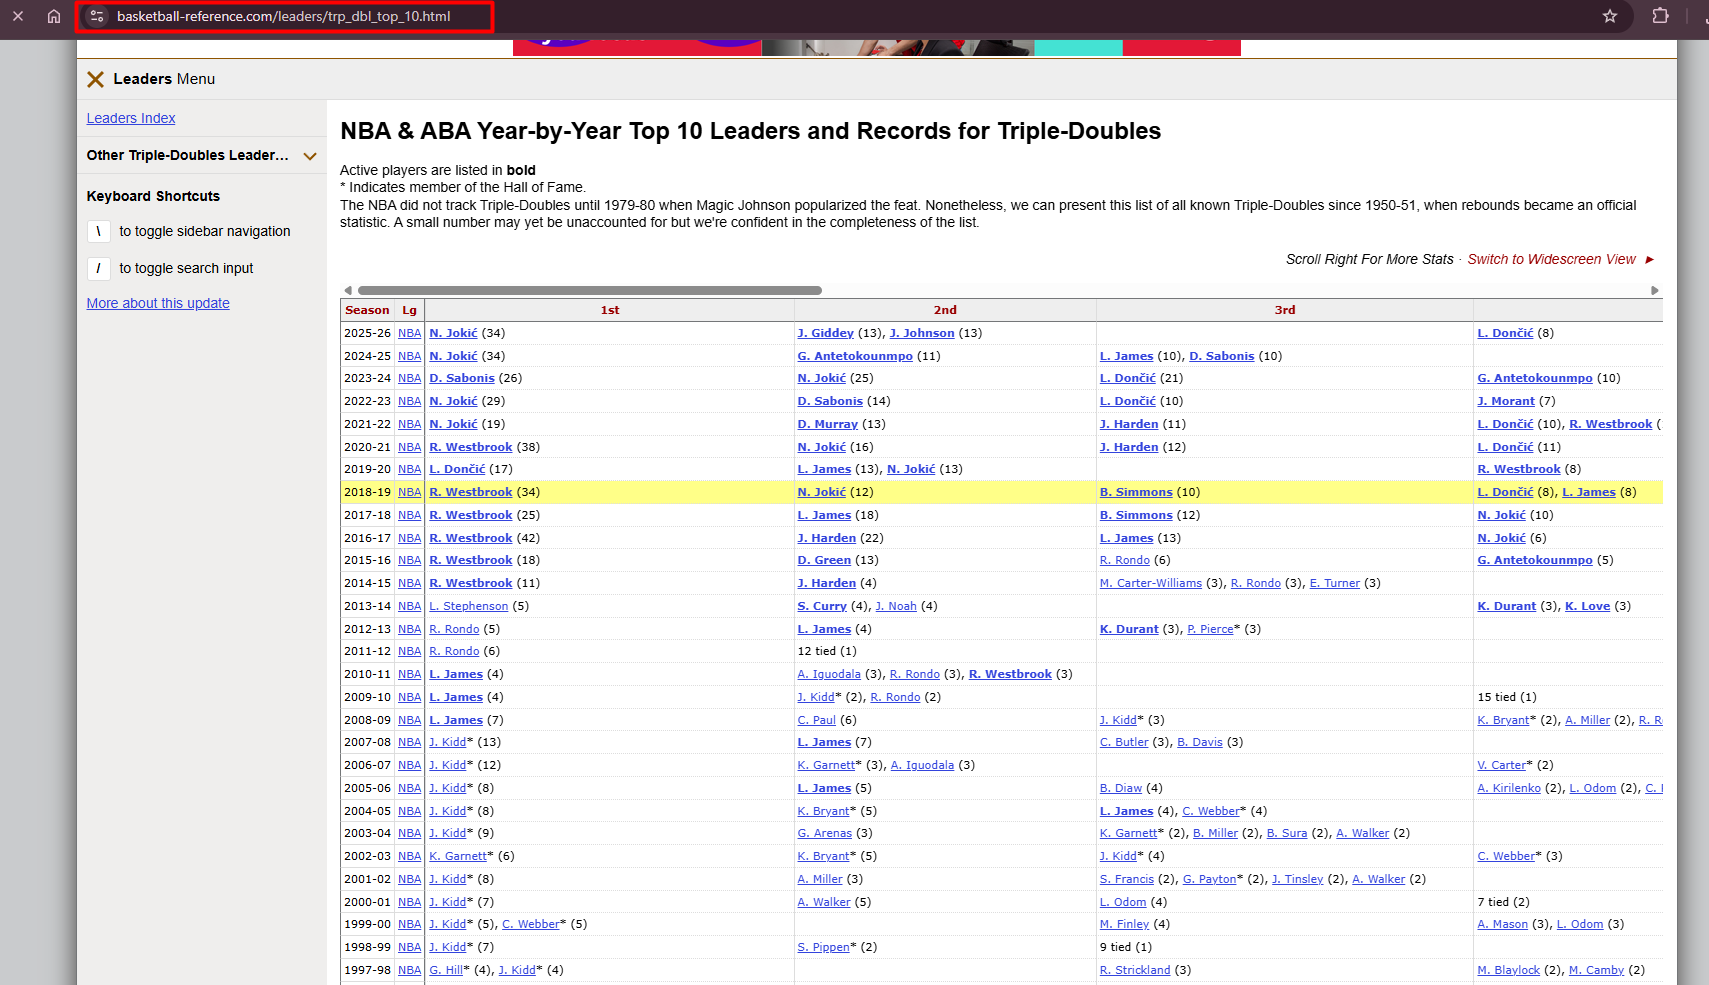

**Figure 1.** Basketball-Reference page for year-by-year triple-double leaders.

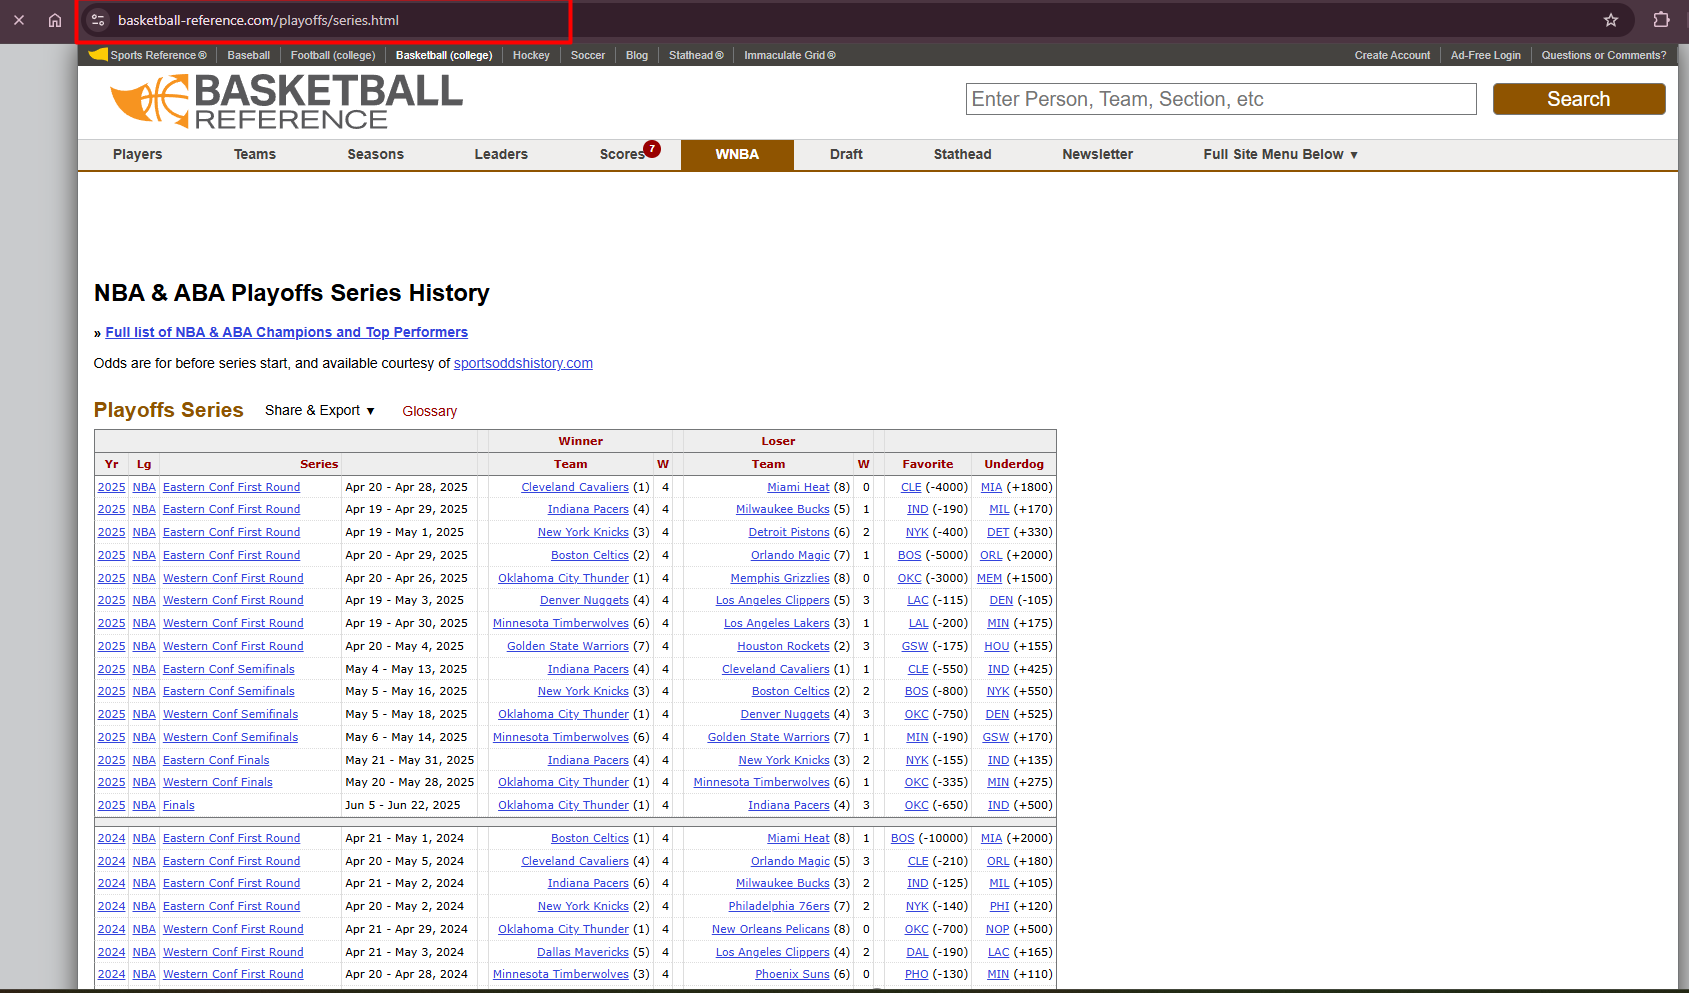

**Figure 2.** Basketball-Reference playoff series history page used to identify postseason outcomes.

In [1]:
from IPython.display import Image, display, Markdown

display(Image("triple_double_source_screenshot.png", width=900))
display(Markdown("**Figure 1.** Basketball-Reference page for year-by-year triple-double leaders."))

display(Image("playoff_series_source_screenshot.png", width=900))
display(Markdown("**Figure 2.** Basketball-Reference playoff series history page used to identify postseason outcomes."))

In [2]:
import pandas as pd
import numpy as np
import re
import unicodedata
from IPython.display import display
import os
import time
import random
import requests

TRIPLE_URL = "https://www.basketball-reference.com/leaders/trp_dbl_top_10.html"
PLAYOFF_URL = "https://www.basketball-reference.com/playoffs/series.html"
CACHE_DIR = "html_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

In [3]:
def read_html_tables(url, cache_name=None, sleep_range=(3, 6), match=None, attrs=None):
    """
    Read HTML tables with cache support.

    Behavior:
    - If cached file exists, read tables from it.
    - Otherwise try reading from the live URL.
    - If live URL fails and cache exists, fall back to cache.
    - Supports pandas read_html filters like `match` and `attrs`.
    """
    if cache_name is None:
        cache_name = url.split("/")[-1].replace(".html", "") + ".html"

    cache_path = os.path.join(CACHE_DIR, cache_name)

    read_kwargs = {}
    if match is not None:
        read_kwargs["match"] = match
    if attrs is not None:
        read_kwargs["attrs"] = attrs

    if os.path.exists(cache_path):
        print(f"Loading from cache: {cache_path}")
        return pd.read_html(cache_path, **read_kwargs)

    try:
        print(f"Downloading: {url}")
        tables = pd.read_html(url, **read_kwargs)

        # optional polite pause after live hit
        time.sleep(random.uniform(*sleep_range))

        return tables

    except Exception as e:
        print(f"Live read failed: {e}")

        if os.path.exists(cache_path):
            print(f"Falling back to cache: {cache_path}")
            return pd.read_html(cache_path, **read_kwargs)

        raise

def flatten_columns(df):
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [
            " ".join(str(x).strip() for x in col if str(x).strip() != "")
            for col in df.columns
        ]
    else:
        df.columns = [str(c).strip() for c in df.columns]
    return df

def remove_repeated_header_rows(df):
    """Remove repeated header rows that sometimes appear inside Sports Reference tables."""
    first_col = df.columns[0]
    return df[df[first_col].astype(str) != str(first_col)].copy()

def normalize_text(value):
    if pd.isna(value):
        return value
    value = str(value).strip()
    value = unicodedata.normalize("NFKD", value)
    value = "".join(ch for ch in value if not unicodedata.combining(ch))
    value = re.sub(r"\s+", " ", value)
    return value

def bref_short_name(full_name):
    """
    Convert a full Basketball-Reference player name to the short style used
    on leaderboard pages, such as:
    'Nikola Jokic' -> 'N. Jokic'
    'LeBron James' -> 'L. James'
    """
    if pd.isna(full_name):
        return full_name

    name = normalize_text(full_name)
    parts = name.split()
    if len(parts) < 2:
        return name

    first_initial = parts[0][0]
    last_name = parts[-1]
    return f"{first_initial}. {last_name}"


def normalize_merge_name(text):
    """
    Normalize player display names for merging by:
    - converting to lowercase
    - removing accents/diacritics
    - removing trailing asterisks
    - collapsing extra spaces
    """
    if pd.isna(text):
        return np.nan

    text = str(text).strip()

    # Remove accents, e.g. Jokić -> Jokic, Dončić -> Doncic
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))

    # Remove asterisks and extra punctuation noise
    text = text.replace("*", "")
    text = re.sub(r"\s+", " ", text)

    return text.lower().strip()

def season_to_playoff_year(season_text):
    """
    Convert a Basketball-Reference season label to the playoff year, such as:
    '1990-91' -> 1991
    '1999-00' -> 2000
    '2024-25' -> 2025
    '2025-26' -> 2026
    """
    season_text = str(season_text).strip()
    match = re.match(r"(\d{4})-(\d{2})", season_text)

    if not match:
        return np.nan

    start_year = int(match.group(1))
    end_two_digits = int(match.group(2))

    century = (start_year // 100) * 100
    end_year = century + end_two_digits

    if end_year < start_year:
        end_year += 100

    return end_year

## Load and inspect the triple-double leader table
The first source page contains one row per season and columns for 1st, 2nd, 3rd, and so on. We only need the season and the top value, but we still clean it carefully before extracting the leader name and count.

In [4]:
triple_tables = read_html_tables(
    TRIPLE_URL,
    cache_name="trp_dbl_top_10.html",
    attrs={"id": "leaders"}
)
print("Number of matched tables:", len(triple_tables))

triple_raw = flatten_columns(triple_tables[0].copy())
print(triple_raw.columns)
triple_raw.head()

Loading from cache: html_cache\trp_dbl_top_10.html
Number of matched tables: 1
Index(['Season', 'Lg', '1st', '2nd', '3rd', '4th', '5th', '6th', '7th', '8th',
       '9th', '10th'],
      dtype='object')


,Season,Lg,1st,2nd,3rd,4th,5th,6th,7th,8th,9th,10th
0,2025-26,NBA,N. Jokić (34),"J. Giddey (13), J. Johnson (13)",NaN,L. Dončić (8),R. Westbrook (6),S. Castle (5),A. Şengün (4),6 tied (3),NaN,NaN
1,2024-25,NBA,N. Jokić (34),G. Antetokounmpo (11),"L. James (10), D. Sabonis (10)",NaN,"C. Cunningham (9), J. Hart (9)",NaN,J. Giddey (7),L. Dončić (5),"A. Şengün (4), R. Westbrook (4)",NaN
2,2023-24,NBA,D. Sabonis (26),N. Jokić (25),L. Dončić (21),G. Antetokounmpo (10),J. Hart (6),L. James (5),S. Barnes (4),"J. Giddey (3), J. Harden (3)",NaN,6 tied (2)
3,2022-23,NBA,N. Jokić (29),D. Sabonis (14),L. Dončić (10),J. Morant (7),G. Antetokounmpo (6),J. Harden (5),"J. Giddey (4), R. Westbrook (4)",NaN,"K. Anderson (3), L. Ball (3)",NaN
4,2021-22,NBA,N. Jokić (19),D. Murray (13),J. Harden (11),"L. Dončić (10), R. Westbrook (10)",NaN,L. James (6),"L. Ball (5), D. Sabonis (5)",NaN,"G. Antetokounmpo (4), J. Butler (4), K. Durant...",NaN


In [5]:
td = triple_raw.copy()

# Keep season and first-place entry only.
td = td[["Season", "1st"]].copy()

# Example cell: 'N. Jokić (34)'
td[["LeaderDisplayName", "TripleDoubles"]] = td["1st"].astype(str).str.extract(r"^(.*)\s\((\d+)\)$")
td["TripleDoubles"] = pd.to_numeric(td["TripleDoubles"], errors="coerce")

# Season start year from labels such as 1990-91 or 2025-26
td["SeasonStartYear"] = pd.to_numeric(
    td["Season"].astype(str).str.extract(r"(\d{4})")[0],
    errors="coerce"
)

# Keep modern seasons for this project
td = td[td["SeasonStartYear"] >= 1990].copy()

td["PlayoffYear"] = td["Season"].apply(season_to_playoff_year)

# The page can sometimes store multiple names in one cell for ties.
# We split leaders so every row in the final dataset represents one player-season.
td["LeaderDisplayName"] = td["LeaderDisplayName"].astype(str).str.split(r"\s*,\s*")
td = td.explode("LeaderDisplayName").reset_index(drop=True)

td["LeaderDisplayName"] = td["LeaderDisplayName"].str.strip()
td["IsTiedLeader"] = td.groupby("Season")["LeaderDisplayName"].transform("count").gt(1)

td.head(10)

,Season,1st,LeaderDisplayName,TripleDoubles,SeasonStartYear,PlayoffYear,IsTiedLeader
0,2025-26,N. Jokić (34),N. Jokić,34,2025,2026,False
1,2024-25,N. Jokić (34),N. Jokić,34,2024,2025,False
2,2023-24,D. Sabonis (26),D. Sabonis,26,2023,2024,False
3,2022-23,N. Jokić (29),N. Jokić,29,2022,2023,False
4,2021-22,N. Jokić (19),N. Jokić,19,2021,2022,False
5,2020-21,R. Westbrook (38),R. Westbrook,38,2020,2021,False
6,2019-20,L. Dončić (17),L. Dončić,17,2019,2020,False
7,2018-19,R. Westbrook (34),R. Westbrook,34,2018,2019,False
8,2017-18,R. Westbrook (25),R. Westbrook,25,2017,2018,False
9,2016-17,R. Westbrook (42),R. Westbrook,42,2016,2017,False


## Build a season-by-season lookup for the leader's team
The leaders page does not consistently provide the team in a way that is easy to merge with playoff results. That is the main reason the earlier notebook produced missing values in the final result.

To fix that, this notebook reads each season's per-game table directly from Basketball-Reference and matches the season leader to that season's player row.

In [6]:
def load_season_player_team_lookup(playoff_year):
    """
    For a playoff year like 2025, read the NBA 2025 per-game page and return
    a compact table that maps players to teams for that season.
    """
    try:
        playoff_year = int(playoff_year)
        url = f"https://www.basketball-reference.com/leagues/NBA_{playoff_year}_per_game.html"
        cache_name = f"NBA_{playoff_year}_per_game.html"

        tables = read_html_tables(
            url,
            cache_name=cache_name,
            attrs={"id": "per_game_stats"}
        )

        season_df = flatten_columns(tables[0].copy())
        season_df = remove_repeated_header_rows(season_df)

        player_col = next(c for c in season_df.columns if "Player" in str(c))
        team_col = next(c for c in season_df.columns if c in {"Tm", "Team"} or "Tm" in str(c) or "Team" in str(c))

        games_candidates = [c for c in season_df.columns if c in {"G", "Games"} or str(c).endswith(" G")]
        games_col = games_candidates[0] if games_candidates else None

        keep_cols = [player_col, team_col] + ([games_col] if games_col else [])
        season_df = season_df[keep_cols].copy()
        season_df = season_df.rename(columns={player_col: "PlayerFullName", team_col: "TeamAbbrev"})

        if games_col:
            season_df = season_df.rename(columns={games_col: "Games"})
            season_df["Games"] = pd.to_numeric(season_df["Games"], errors="coerce")
        else:
            season_df["Games"] = np.nan

        season_df["PlayerFullName"] = season_df["PlayerFullName"].apply(normalize_text)
        season_df["LeaderDisplayName"] = season_df["PlayerFullName"].apply(bref_short_name)
        season_df["PlayoffYear"] = playoff_year

        # If a player appears for multiple teams in a season, prefer a real team over TOT.
        # If there are still multiple real teams, keep the one with the most games.
        season_df["TeamPriority"] = np.where(season_df["TeamAbbrev"].eq("TOT"), 1, 0)
        season_df = season_df.sort_values(
            ["LeaderDisplayName", "TeamPriority", "Games", "TeamAbbrev"],
            ascending=[True, True, False, True]
        )

        season_df = season_df.drop_duplicates(
            subset=["PlayoffYear", "LeaderDisplayName"],
            keep="first"
        ).reset_index(drop=True)

        return season_df[["PlayoffYear", "LeaderDisplayName", "PlayerFullName", "TeamAbbrev", "Games"]]

    except Exception as e:
        print(f"Could not load season lookup for {playoff_year}: {e}")
        return pd.DataFrame(columns=["PlayoffYear", "LeaderDisplayName", "PlayerFullName", "TeamAbbrev", "Games"])

In [7]:
lookup_frames = []

for year in sorted(td["PlayoffYear"].dropna().astype(int).unique()):
    season_lookup = load_season_player_team_lookup(year)

    if season_lookup is not None and not season_lookup.empty:
        lookup_frames.append(season_lookup)
        print(f"Loaded player-team lookup for {year}: {len(season_lookup)} rows")
    else:
        print(f"No player-team lookup available for {year}")

if lookup_frames:
    player_team_lookup = pd.concat(lookup_frames, ignore_index=True)
else:
    player_team_lookup = pd.DataFrame(
        columns=["PlayoffYear", "LeaderDisplayName", "PlayerFullName", "TeamAbbrev", "Games"]
    )

player_team_lookup.head()

Loading from cache: html_cache\NBA_1991_per_game.html
Loaded player-team lookup for 1991: 380 rows
Loading from cache: html_cache\NBA_1992_per_game.html
Loaded player-team lookup for 1992: 377 rows
Loading from cache: html_cache\NBA_1993_per_game.html
Loaded player-team lookup for 1993: 383 rows
Loading from cache: html_cache\NBA_1994_per_game.html
Loaded player-team lookup for 1994: 396 rows
Loading from cache: html_cache\NBA_1995_per_game.html
Loaded player-team lookup for 1995: 399 rows
Loading from cache: html_cache\NBA_1996_per_game.html
Loaded player-team lookup for 1996: 420 rows
Loading from cache: html_cache\NBA_1997_per_game.html
Loaded player-team lookup for 1997: 430 rows
Loading from cache: html_cache\NBA_1998_per_game.html
Loaded player-team lookup for 1998: 428 rows
Loading from cache: html_cache\NBA_1999_per_game.html
Loaded player-team lookup for 1999: 428 rows
Loading from cache: html_cache\NBA_2000_per_game.html
Loaded player-team lookup for 2000: 427 rows
Loading fr

,PlayoffYear,LeaderDisplayName,PlayerFullName,TeamAbbrev,Games
0,1991,A. Abdelnaby,Alaa Abdelnaby,POR,43.0
1,1991,A. Bonner,Anthony Bonner,SAC,34.0
2,1991,A. Caldwell,Adrian Caldwell,HOU,42.0
3,1991,A. Carr,Antoine Carr,SAC,77.0
4,1991,A. Cook,Anthony Cook,DEN,58.0


In [8]:
td["LeaderKey"] = td["LeaderDisplayName"].apply(normalize_merge_name)
player_team_lookup["LeaderKey"] = player_team_lookup["LeaderDisplayName"].apply(normalize_merge_name)

td_leaders = td.merge(
    player_team_lookup.drop(columns=["LeaderDisplayName"]),
    on=["PlayoffYear", "LeaderKey"],
    how="left"
)

print("Leader rows:", len(td_leaders))
print("Missing team matches:", td_leaders["TeamAbbrev"].isna().sum())

td_leaders.head(10)


Leader rows: 41
Missing team matches: 5


,Season,1st,LeaderDisplayName,TripleDoubles,SeasonStartYear,PlayoffYear,IsTiedLeader,LeaderKey,PlayerFullName,TeamAbbrev,Games
0,2025-26,N. Jokić (34),N. Jokić,34,2025,2026,False,n. jokic,Nikola Jokic,DEN,64.0
1,2024-25,N. Jokić (34),N. Jokić,34,2024,2025,False,n. jokic,Nikola Jokic,DEN,70.0
2,2023-24,D. Sabonis (26),D. Sabonis,26,2023,2024,False,d. sabonis,Domantas Sabonis,SAC,82.0
3,2022-23,N. Jokić (29),N. Jokić,29,2022,2023,False,n. jokic,Nikola Jokic,DEN,69.0
4,2021-22,N. Jokić (19),N. Jokić,19,2021,2022,False,n. jokic,Nikola Jokic,DEN,74.0
5,2020-21,R. Westbrook (38),R. Westbrook,38,2020,2021,False,r. westbrook,Russell Westbrook,WAS,65.0
6,2019-20,L. Dončić (17),L. Dončić,17,2019,2020,False,l. doncic,Luka Doncic,DAL,61.0
7,2018-19,R. Westbrook (34),R. Westbrook,34,2018,2019,False,r. westbrook,Russell Westbrook,OKC,73.0
8,2017-18,R. Westbrook (25),R. Westbrook,25,2017,2018,False,r. westbrook,Russell Westbrook,OKC,80.0
9,2016-17,R. Westbrook (42),R. Westbrook,42,2016,2017,False,r. westbrook,Russell Westbrook,OKC,81.0


In [9]:
missing_team_matches = td_leaders[td_leaders["TeamAbbrev"].isna()].copy()
missing_team_matches[["Season", "PlayoffYear", "LeaderDisplayName", "TripleDoubles"]].head(20)

,Season,PlayoffYear,LeaderDisplayName,TripleDoubles
26,1999-00,2000,J. Kidd* (5),5
29,1997-98,1998,G. Hill* (4),4
36,1991-92,1992,M. Jordan* (2),2
37,1991-92,1992,G. Payton* (2),2
38,1991-92,1992,S. Pippen* (2),2


## Handle team abbreviations

The regular-season player lookup table uses team abbreviations such as `DEN`, `DAL`, and `OKC`, while the playoff history page uses full franchise names. To merge these sources correctly, we convert each team abbreviation into a standardized full team name that matches the playoff results table.

In [14]:
TEAM_MAP = {
    "ATL": "Atlanta Hawks",
    "BOS": "Boston Celtics",
    "BRK": "Brooklyn Nets",
    "BKN": "Brooklyn Nets",
    "CHI": "Chicago Bulls",
    "CHO": "Charlotte Hornets",
    "CHH": "Charlotte Hornets",
    "CHA": "Charlotte Hornets",
    "CLE": "Cleveland Cavaliers",
    "DAL": "Dallas Mavericks",
    "DEN": "Denver Nuggets",
    "DET": "Detroit Pistons",
    "GSW": "Golden State Warriors",
    "HOU": "Houston Rockets",
    "IND": "Indiana Pacers",
    "LAC": "Los Angeles Clippers",
    "LAL": "Los Angeles Lakers",
    "MEM": "Memphis Grizzlies",
    "MIA": "Miami Heat",
    "MIL": "Milwaukee Bucks",
    "MIN": "Minnesota Timberwolves",
    "NJN": "New Jersey Nets",
    "BRN": "New Jersey Nets",
    "NOH": "New Orleans Hornets",
    "NOK": "New Orleans/Oklahoma City Hornets",
    "NOP": "New Orleans Pelicans",
    "NYK": "New York Knicks",
    "OKC": "Oklahoma City Thunder",
    "ORL": "Orlando Magic",
    "PHI": "Philadelphia 76ers",
    "PHO": "Phoenix Suns",
    "PHX": "Phoenix Suns",
    "POR": "Portland Trail Blazers",
    "SAC": "Sacramento Kings",
    "SAS": "San Antonio Spurs",
    "SEA": "Seattle SuperSonics",
    "TOR": "Toronto Raptors",
    "UTA": "Utah Jazz",
    "UTH": "Utah Jazz",
    "VAN": "Vancouver Grizzlies",
    "WAS": "Washington Wizards",
    "WSB": "Washington Bullets",
}

td_leaders["Team"] = td_leaders["TeamAbbrev"].map(TEAM_MAP)
td_leaders["Team"] = td_leaders["Team"].fillna(td_leaders["TeamAbbrev"])
td_leaders["Team"] = td_leaders["Team"].fillna("Unknown")

td_leaders.head(10)

,Season,1st,LeaderDisplayName,TripleDoubles,SeasonStartYear,PlayoffYear,IsTiedLeader,LeaderKey,PlayerFullName,TeamAbbrev,Games,Team
0,2025-26,N. Jokić (34),N. Jokić,34,2025,2026,False,n. jokic,Nikola Jokic,DEN,64.0,Denver Nuggets
1,2024-25,N. Jokić (34),N. Jokić,34,2024,2025,False,n. jokic,Nikola Jokic,DEN,70.0,Denver Nuggets
2,2023-24,D. Sabonis (26),D. Sabonis,26,2023,2024,False,d. sabonis,Domantas Sabonis,SAC,82.0,Sacramento Kings
3,2022-23,N. Jokić (29),N. Jokić,29,2022,2023,False,n. jokic,Nikola Jokic,DEN,69.0,Denver Nuggets
4,2021-22,N. Jokić (19),N. Jokić,19,2021,2022,False,n. jokic,Nikola Jokic,DEN,74.0,Denver Nuggets
5,2020-21,R. Westbrook (38),R. Westbrook,38,2020,2021,False,r. westbrook,Russell Westbrook,WAS,65.0,Washington Wizards
6,2019-20,L. Dončić (17),L. Dončić,17,2019,2020,False,l. doncic,Luka Doncic,DAL,61.0,Dallas Mavericks
7,2018-19,R. Westbrook (34),R. Westbrook,34,2018,2019,False,r. westbrook,Russell Westbrook,OKC,73.0,Oklahoma City Thunder
8,2017-18,R. Westbrook (25),R. Westbrook,25,2017,2018,False,r. westbrook,Russell Westbrook,OKC,80.0,Oklahoma City Thunder
9,2016-17,R. Westbrook (42),R. Westbrook,42,2016,2017,False,r. westbrook,Russell Westbrook,OKC,81.0,Oklahoma City Thunder


## Load and clean playoff series history

This table is used to determine how far each team advanced in the postseason for each playoff year. After loading the playoff history page, the table is cleaned so it can be merged with the triple-double leader dataset.

In [22]:
playoff_tables = read_html_tables(
    PLAYOFF_URL,
    cache_name="series.html",
    attrs={"id": "playoffs_series"}
)
print("Number of matched tables:", len(playoff_tables))

playoff_raw = flatten_columns(playoff_tables[0].copy())
playoff_raw = remove_repeated_header_rows(playoff_raw)
playoff_raw.head(100)

Loading from cache: html_cache\series.html
Number of matched tables: 1


,Unnamed: 0_level_0 Yr,Unnamed: 1_level_0 Lg,Unnamed: 2_level_0 Series,Unnamed: 3_level_0 Unnamed: 3_level_1,Unnamed: 4_level_0 Unnamed: 4_level_1,Winner Team,Winner W,Unnamed: 7_level_0 Unnamed: 7_level_1,Loser Team,Loser W,Unnamed: 10_level_0 Unnamed: 10_level_1,Unnamed: 11_level_0 Favorite,Unnamed: 12_level_0 Underdog
0,2025,NBA,Eastern Conf First Round,"Apr 20 - Apr 28, 2025",NaN,Cleveland Cavaliers (1),4,NaN,Miami Heat (8),0,NaN,CLE (-4000),MIA (+1800)
1,2025,NBA,Eastern Conf First Round,"Apr 19 - Apr 29, 2025",NaN,Indiana Pacers (4),4,NaN,Milwaukee Bucks (5),1,NaN,IND (-190),MIL (+170)
2,2025,NBA,Eastern Conf First Round,"Apr 19 - May 1, 2025",NaN,New York Knicks (3),4,NaN,Detroit Pistons (6),2,NaN,NYK (-400),DET (+330)
3,2025,NBA,Eastern Conf First Round,"Apr 20 - Apr 29, 2025",NaN,Boston Celtics (2),4,NaN,Orlando Magic (7),1,NaN,BOS (-5000),ORL (+2000)
4,2025,NBA,Western Conf First Round,"Apr 20 - Apr 26, 2025",NaN,Oklahoma City Thunder (1),4,NaN,Memphis Grizzlies (8),0,NaN,OKC (-3000),MEM (+1500)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,2019,NBA,Eastern Conf First Round,"Apr 14 - Apr 22, 2019",NaN,Milwaukee Bucks (1),4,NaN,Detroit Pistons (8),0,NaN,MIL (-3500),DET (+1750)
97,2019,NBA,Eastern Conf First Round,"Apr 13 - Apr 23, 2019",NaN,Toronto Raptors (2),4,NaN,Orlando Magic (7),1,NaN,TOR (-1200),ORL (+775)
98,2019,NBA,Eastern Conf First Round,"Apr 13 - Apr 23, 2019",NaN,Philadelphia 76ers (3),4,NaN,Brooklyn Nets (6),1,NaN,PHI (-600),BRK (+450)


In [23]:
ps = playoff_raw.copy()

year_col = next(c for c in ps.columns if c in {"Yr", "Year"} or "Yr" in str(c))
series_col = next(c for c in ps.columns if "Series" in str(c))
winner_col = next(c for c in ps.columns if "Winner Team" in str(c))
loser_col = next(c for c in ps.columns if "Loser Team" in str(c))

league_candidates = [c for c in ps.columns if c in {"Lg", "League"} or "Lg" in str(c) or "League" in str(c)]
league_col = league_candidates[0] if league_candidates else None

keep_cols = [year_col, series_col, winner_col, loser_col] + ([league_col] if league_col else [])
ps = ps[keep_cols].copy()

rename_map = {
    year_col: "Year",
    series_col: "Series",
    winner_col: "Winner",
    loser_col: "Loser",
}
if league_col:
    rename_map[league_col] = "League"

ps = ps.rename(columns=rename_map)

if "League" in ps.columns:
    ps = ps[ps["League"] == "NBA"].copy()

ps["Year"] = pd.to_numeric(ps["Year"], errors="coerce")
ps = ps[ps["Year"] >= 1991].copy()

ps.head(100)

,Year,Series,Winner,Loser,League
0,2025,Eastern Conf First Round,Cleveland Cavaliers (1),Miami Heat (8),NBA
1,2025,Eastern Conf First Round,Indiana Pacers (4),Milwaukee Bucks (5),NBA
2,2025,Eastern Conf First Round,New York Knicks (3),Detroit Pistons (6),NBA
3,2025,Eastern Conf First Round,Boston Celtics (2),Orlando Magic (7),NBA
4,2025,Western Conf First Round,Oklahoma City Thunder (1),Memphis Grizzlies (8),NBA
...,...,...,...,...,...
101,2019,Western Conf First Round,Denver Nuggets (2),San Antonio Spurs (7),NBA
102,2019,Western Conf First Round,Portland Trail Blazers (3),Oklahoma City Thunder (6),NBA
103,2019,Western Conf First Round,Houston Rockets (4),Utah Jazz (5),NBA
104,2019,Eastern Conf Semifinals,Milwaukee Bucks (1),Boston Celtics (4),NBA


In [25]:
# Remove seed numbers from playoff team names, e.g.:
# 'Cleveland Cavaliers (1)' -> 'Cleveland Cavaliers'
ps["Winner"] = ps["Winner"].astype(str).str.replace(r"\s*\(\d+\)$", "", regex=True).str.strip()
ps["Loser"] = ps["Loser"].astype(str).str.replace(r"\s*\(\d+\)$", "", regex=True).str.strip()

ps.head(100)

,Year,Series,Winner,Loser,League
0,2025,Eastern Conf First Round,Cleveland Cavaliers,Miami Heat,NBA
1,2025,Eastern Conf First Round,Indiana Pacers,Milwaukee Bucks,NBA
2,2025,Eastern Conf First Round,New York Knicks,Detroit Pistons,NBA
3,2025,Eastern Conf First Round,Boston Celtics,Orlando Magic,NBA
4,2025,Western Conf First Round,Oklahoma City Thunder,Memphis Grizzlies,NBA
...,...,...,...,...,...
101,2019,Western Conf First Round,Denver Nuggets,San Antonio Spurs,NBA
102,2019,Western Conf First Round,Portland Trail Blazers,Oklahoma City Thunder,NBA
103,2019,Western Conf First Round,Houston Rockets,Utah Jazz,NBA
104,2019,Eastern Conf Semifinals,Milwaukee Bucks,Boston Celtics,NBA


In [26]:
def standardize_round(series_name):
    s = normalize_text(series_name).lower()

    if "nba finals" in s or s == "finals":
        return "NBA Finals"
    if "conference finals" in s or "division finals" in s:
        return "Conference Finals"
    if "conference semifinals" in s or "division semifinals" in s or "conference semi" in s:
        return "Conference Semifinals"
    if "first round" in s or "conference quarterfinals" in s:
        return "First Round"
    if "play-in" in s:
        return "Play-In"
    return "Other"

ROUND_RANK = {
    "Other": -1,
    "Play-In": 0,
    "First Round": 1,
    "Conference Semifinals": 2,
    "Conference Finals": 3,
    "NBA Finals": 4,
}

ps["Round"] = ps["Series"].apply(standardize_round)
ps["RoundRank"] = ps["Round"].map(ROUND_RANK)

ps[["Year", "Series", "Round", "RoundRank"]].head(15)

,Year,Series,Round,RoundRank
0,2025,Eastern Conf First Round,First Round,1
1,2025,Eastern Conf First Round,First Round,1
2,2025,Eastern Conf First Round,First Round,1
3,2025,Eastern Conf First Round,First Round,1
4,2025,Western Conf First Round,First Round,1
5,2025,Western Conf First Round,First Round,1
6,2025,Western Conf First Round,First Round,1
7,2025,Western Conf First Round,First Round,1
8,2025,Eastern Conf Semifinals,Other,-1
9,2025,Eastern Conf Semifinals,Other,-1


In [28]:
winner_rows = ps[["Year", "Winner", "Round", "RoundRank"]].rename(columns={"Winner": "Team"})
loser_rows = ps[["Year", "Loser", "Round", "RoundRank"]].rename(columns={"Loser": "Team"})

team_rounds = pd.concat([winner_rows, loser_rows], ignore_index=True)

team_best = (
    team_rounds
    .sort_values(["Year", "Team", "RoundRank"])
    .groupby(["Year", "Team"], as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

nba_finals = ps[ps["Round"] == "NBA Finals"].copy()

champions = nba_finals[["Year", "Winner"]].rename(columns={"Winner": "Team"})
champions["FinalPlayoffResult"] = "Champion"

runners_up = nba_finals[["Year", "Loser"]].rename(columns={"Loser": "Team"})
runners_up["FinalPlayoffResult"] = "NBA Finals"

final_results = pd.concat([champions, runners_up], ignore_index=True)

playoff_outcomes = team_best.rename(columns={"Round": "PlayoffRoundReached"})
playoff_outcomes["FinalPlayoffResult"] = playoff_outcomes["PlayoffRoundReached"]

playoff_outcomes = playoff_outcomes.merge(
    final_results,
    on=["Year", "Team"],
    how="left",
    suffixes=("", "_override")
)

playoff_outcomes["FinalPlayoffResult"] = playoff_outcomes["FinalPlayoffResult_override"].fillna(
    playoff_outcomes["FinalPlayoffResult"]
)

playoff_outcomes = playoff_outcomes.drop(columns=["FinalPlayoffResult_override"])
playoff_outcomes.head(100)

,Year,Team,PlayoffRoundReached,RoundRank,FinalPlayoffResult
0,1991,Atlanta Hawks,First Round,1,First Round
1,1991,Boston Celtics,First Round,1,First Round
2,1991,Chicago Bulls,NBA Finals,4,Champion
3,1991,Detroit Pistons,First Round,1,First Round
4,1991,Golden State Warriors,First Round,1,First Round
...,...,...,...,...,...
95,1996,Utah Jazz,First Round,1,First Round
96,1997,Atlanta Hawks,First Round,1,First Round
97,1997,Charlotte Hornets,First Round,1,First Round
98,1997,Chicago Bulls,NBA Finals,4,Champion


## Merge season leaders with playoff outcomes

At this stage, the notebook has three cleaned components:
- the season triple-double leader and total triple-doubles
- the team that player was on during that season
- the playoff outcome for each team in each year

These pieces are now merged together to create the final dataset for analysis.

In [32]:
dataset = td_leaders.merge(
    playoff_outcomes,
    left_on=["PlayoffYear", "Team"],
    right_on=["Year", "Team"],
    how="left"
)

latest_completed_playoff_year = int(playoff_outcomes["Year"].max())

dataset["SeasonStatus"] = np.where(
    dataset["PlayoffYear"] > latest_completed_playoff_year,
    "Season In Progress",
    "Completed"
)

dataset["PlayoffQualification"] = np.where(
    dataset["SeasonStatus"].eq("Season In Progress"),
    "Not Yet Available",
    np.where(dataset["PlayoffRoundReached"].notna(), "Made Playoffs", "Did Not Make Playoffs")
)

dataset["PlayoffRoundReached"] = np.where(
    dataset["SeasonStatus"].eq("Season In Progress"),
    "Not Yet Available",
    dataset["PlayoffRoundReached"].fillna("Did Not Make Playoffs")
)

dataset["FinalPlayoffResult"] = np.where(
    dataset["SeasonStatus"].eq("Season In Progress"),
    "Not Yet Available",
    dataset["FinalPlayoffResult"].fillna("Did Not Make Playoffs")
)

# Clean unresolved player/team values
dataset["PlayerFullName"] = dataset["PlayerFullName"].fillna(dataset["LeaderDisplayName"])
dataset["TeamAbbrev"] = dataset["TeamAbbrev"].fillna("Unknown")
dataset["Team"] = dataset["Team"].fillna("Unknown")

dataset = dataset[[
    "Season",
    "SeasonStartYear",
    "PlayoffYear",
    "SeasonStatus",
    "LeaderDisplayName",
    "PlayerFullName",
    "TripleDoubles",
    "IsTiedLeader",
    "TeamAbbrev",
    "Team",
    "PlayoffQualification",
    "PlayoffRoundReached",
    "FinalPlayoffResult"
]].copy()

dataset = dataset.rename(columns={
    "LeaderDisplayName": "PlayerLeaderboardName",
    "PlayerFullName": "Player"
})

dataset["PlayerLeaderboardName"] = (
    dataset["PlayerLeaderboardName"]
    .astype(str)
    .str.replace(r"\s*\(\d+\)$", "", regex=True)
    .str.strip()
)

dataset["Player"] = (
    dataset["Player"]
    .astype(str)
    .str.replace(r"\s*\(\d+\)$", "", regex=True)
    .str.strip()
)

dataset["TeamAbbrev"] = dataset["TeamAbbrev"].replace({
    "TOT": "Unknown",
    "2TM": "Unknown",
    "3TM": "Unknown"
})

dataset["Team"] = dataset["Team"].replace({
    "TOT": "Unknown",
    "2TM": "Unknown",
    "3TM": "Unknown"
})

dataset["FinalPlayoffResult"] = np.where(
    (dataset["PlayoffRoundReached"] == "NBA Finals") & (dataset["FinalPlayoffResult"] != "Champion"),
    "Runner-Up",
    dataset["FinalPlayoffResult"]
)

dataset = dataset.sort_values(["SeasonStartYear", "Player"]).reset_index(drop=True)
dataset.head(100)

,Season,SeasonStartYear,PlayoffYear,SeasonStatus,PlayerLeaderboardName,Player,TripleDoubles,IsTiedLeader,TeamAbbrev,Team,PlayoffQualification,PlayoffRoundReached,FinalPlayoffResult
0,1990-91,1990,1991,Completed,M. Johnson*,Magic Johnson,13,False,LAL,Los Angeles Lakers,Made Playoffs,NBA Finals,Runner-Up
1,1991-92,1991,1992,Completed,D. Robinson*,David Robinson,2,True,SAS,San Antonio Spurs,Made Playoffs,First Round,First Round
2,1991-92,1991,1992,Completed,G. Payton*,G. Payton*,2,True,Unknown,Unknown,Did Not Make Playoffs,Did Not Make Playoffs,Did Not Make Playoffs
3,1991-92,1991,1992,Completed,M. Jordan*,M. Jordan*,2,True,Unknown,Unknown,Did Not Make Playoffs,Did Not Make Playoffs,Did Not Make Playoffs
4,1991-92,1991,1992,Completed,S. Pippen*,S. Pippen*,2,True,Unknown,Unknown,Did Not Make Playoffs,Did Not Make Playoffs,Did Not Make Playoffs
5,1992-93,1992,1993,Completed,C. Barkley*,Charles Barkley,6,False,PHO,Phoenix Suns,Made Playoffs,NBA Finals,Runner-Up
6,1993-94,1993,1994,Completed,D. Robinson*,David Robinson,5,False,SAS,San Antonio Spurs,Made Playoffs,First Round,First Round
7,1994-95,1994,1995,Completed,J. Kidd*,Jason Kidd,4,False,DAL,Dallas Mavericks,Did Not Make Playoffs,Did Not Make Playoffs,Did Not Make Playoffs
8,1995-96,1995,1996,Completed,G. Hill*,Grant Hill,10,False,DET,Detroit Pistons,Made Playoffs,First Round,First Round
9,1996-97,1996,1997,Completed,G. Hill*,Grant Hill,13,False,DET,Detroit Pistons,Made Playoffs,First Round,First Round


## Discussing the raw HTML gathering

This project uses `pandas.read_html` to extract tables from Basketball-Reference pages rather than relying on a plain `requests` workflow.

That change was necessary because Basketball-Reference may block repeated request-based scraping in notebook environments. To make the process more reliable, the notebook reads tables either from cached local HTML files or directly from the page when needed. It also targets specific table IDs so the correct table is selected from pages that contain many unrelated tables.

The overall HTML-to-dataset process is:

1. use `pandas.read_html()` to read tables from the source HTML
2. use cached downloaded HTML files when live page access is rate-limited
3. target the correct table by table ID or table structure
4. remove repeated header rows that appear inside some tables
5. convert season labels and numeric values into usable columns
6. standardize names and team labels so different tables can be merged
7. combine leader, team, and playoff information into one final dataset

This process explains how the raw HTML was converted into a usable structured dataset for analysis.

## Data cleaning notes

Several cleaning steps were necessary before the final dataset could be built:

- extracted player names and triple-double counts from text such as `N. Jokić (34)`
- split tied first-place entries so each player-season appears as a separate row
- converted season labels such as `1990-91` into playoff years such as `1991`
- removed repeated header rows embedded inside Sports Reference tables
- normalized player names for merging by removing accents, asterisks, and formatting differences
- standardized playoff round names into a consistent set of categories
- removed playoff seed numbers from team names on the playoff history page
- mapped team abbreviations to full team names so merges would work correctly
- replaced aggregate team labels such as `TOT` and `2TM` with `Unknown`
- labeled Finals losers as `Runner-Up` and champions as `Champion`
- labeled ongoing seasons as `Not Yet Available` instead of leaving missing values in the final result

These cleaning steps were important because the original HTML tables were designed for human reading, not for direct analysis in one combined dataset.

## Verify the final dataset
The checks below help confirm that the merged dataset is reasonable.

In [33]:
print("Rows in final dataset:", len(dataset))
print("Distinct seasons:", dataset["Season"].nunique())
print("Distinct players:", dataset["Player"].nunique())
print()

print("Season status counts:")
print(dataset["SeasonStatus"].value_counts(dropna=False))
print()

print("Playoff qualification counts:")
print(dataset["PlayoffQualification"].value_counts(dropna=False))
print()

print("Final playoff result counts:")
print(dataset["FinalPlayoffResult"].value_counts(dropna=False))

Rows in final dataset: 41
Distinct seasons: 36
Distinct players: 19

Season status counts:
SeasonStatus
Completed             40
Season In Progress     1
Name: count, dtype: int64

Playoff qualification counts:
PlayoffQualification
Made Playoffs            31
Did Not Make Playoffs     9
Not Yet Available         1
Name: count, dtype: int64

Final playoff result counts:
FinalPlayoffResult
First Round              26
Did Not Make Playoffs     9
Runner-Up                 4
Champion                  1
Not Yet Available         1
Name: count, dtype: int64


In [34]:
print("Rows where the player's team could not be identified from the season page:")
missing_team = dataset[dataset["Team"].eq("Unknown")].copy()
print("Count:", len(missing_team))
missing_team

Rows where the player's team could not be identified from the season page:
Count: 6


,Season,SeasonStartYear,PlayoffYear,SeasonStatus,PlayerLeaderboardName,Player,TripleDoubles,IsTiedLeader,TeamAbbrev,Team,PlayoffQualification,PlayoffRoundReached,FinalPlayoffResult
2,1991-92,1991,1992,Completed,G. Payton*,G. Payton*,2,True,Unknown,Unknown,Did Not Make Playoffs,Did Not Make Playoffs,Did Not Make Playoffs
3,1991-92,1991,1992,Completed,M. Jordan*,M. Jordan*,2,True,Unknown,Unknown,Did Not Make Playoffs,Did Not Make Playoffs,Did Not Make Playoffs
4,1991-92,1991,1992,Completed,S. Pippen*,S. Pippen*,2,True,Unknown,Unknown,Did Not Make Playoffs,Did Not Make Playoffs,Did Not Make Playoffs
10,1997-98,1997,1998,Completed,G. Hill*,G. Hill*,4,True,Unknown,Unknown,Did Not Make Playoffs,Did Not Make Playoffs,Did Not Make Playoffs
14,1999-00,1999,2000,Completed,J. Kidd*,J. Kidd*,5,True,Unknown,Unknown,Did Not Make Playoffs,Did Not Make Playoffs,Did Not Make Playoffs
22,2007-08,2007,2008,Completed,J. Kidd*,Jason Kidd,13,False,Unknown,Unknown,Did Not Make Playoffs,Did Not Make Playoffs,Did Not Make Playoffs


### Verification discussion

To verify the dataset, I checked several points throughout the notebook:

- confirmed the final number of rows, seasons, and players
- verified that tied first-place leaders were split into separate player-season rows
- checked whether any completed player-season still had an unresolved team match
- confirmed that playoff team names, team abbreviations, and season years aligned correctly during merges
- verified that playoff outcomes such as `Champion`, `Runner-Up`, `First Round`, and `Did Not Make Playoffs` were assigned consistently
- confirmed that ongoing seasons were labeled clearly as `Not Yet Available` instead of being left as missing values

One remaining limitation is the name-matching step between abbreviated leaderboard names and full player names from season tables. The notebook reduces that risk by normalizing accents, removing asterisks and formatting differences, and converting full player names into Basketball-Reference-style short names before matching.

## Save the dataset

This step exports the final cleaned dataset as a CSV file so it can be uploaded to GitHub and reused in later analysis or visualization work.

In [36]:
output_file = "nba_triple_double_leaders_playoff_results_1990_onward.csv"
dataset.to_csv(output_file, index=False)
print("Saved:", output_file)
print("Rows saved:", len(dataset))

Saved: nba_triple_double_leaders_playoff_results_1990_onward.csv
Rows saved: 41


## Final conclusion

This notebook creates a dataset that did not already exist in one analysis-ready table. It combines regular-season triple-double leaders, season-level player-team identification, and team playoff outcomes into one reusable CSV covering seasons from 1990-91 onward.

Compared with the original Basketball-Reference tables, the final dataset is more useful for analysis because it:

- combines information from multiple HTML tables into one file
- converts text-based leaderboard entries into structured player and triple-double fields
- splits tied first-place leaders into separate player-season rows
- standardizes season labels into playoff years for merging
- normalizes player names across different table formats
- maps team abbreviations to full franchise names
- removes playoff seed numbers from playoff-series team names
- standardizes playoff rounds into a consistent set of categories
- labels final outcomes such as `Champion`, `Runner-Up`, `First Round`, and `Did Not Make Playoffs`
- handles ongoing seasons by marking results as `Not Yet Available` instead of leaving missing values

This notebook also improves the data-gathering process itself. Instead of depending on a plain `requests` workflow, it uses `pandas.read_html` with cached HTML files and targeted table selection. That approach is more reliable for Basketball-Reference in notebook environments where repeated live requests may be rate-limited.

The result is a cleaned and reusable dataset that can support later visualization, exploratory analysis, and GitHub-based project work.